In [39]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [40]:
df_original = pd.read_csv('../projet data vis/online_retail_II_merged.csv')
df = df_original.copy()

### Partie 1 : Notebook d’exploration visuelle complète

L'objectif de cette partie est d'utiliser les connaissances acquises sur l'exploration visuelle dans le cours et de l'appliquer afin d'acquérir une compréhension exhaustive du jeu de données.

#### Fiche synthétique des données : source, période couverte, volume, colonnes importantes.

* The Data used here are present in the data folder and are available online at https://archive.ics.uci.edu/dataset/502/online+retail+ii


In [41]:
# let do a copy of the origanl so as not to query the file each time
df = df_original.copy()
df.info()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df["Revenue"] = df["Quantity"] * df["Price"]
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month_name()
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,DayOfWeek
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,December,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,December,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,December,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,December,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,December,Tuesday


In [42]:
# Period of time covered by the data
start , end  = df.InvoiceDate.min(), df.InvoiceDate.max()
print("Start Date: ", start)
print("End Date: ", end)

Start Date:  2009-12-01 07:45:00
End Date:  2011-12-09 12:50:00


In [43]:
# let present the volume of the dataset we are working on
df.shape


(1067371, 12)

### 3.1 Fiche synthétique des données

- **Source :** Online Retail II (UCI Machine Learning Repository).
- **Périmètre :** transactions e-commerce d’un détaillant basé au Royaume-Uni.
- **Période couverte :** 01/12/2009 → 09/12/2011 .
- **Volume :** environ 1,07Mk lignes, 11 colonnes.
- **Granularité temporelle :** Jour , Mois, année.

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 12 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
 8   Revenue      1067371 non-null  float64       
 9   Year         1067371 non-null  int32         
 10  Month        1067371 non-null  object        
 11  DayOfWeek    1067371 non-null  object        
dtypes: datetime64[ns](1), float64(3), int32(1), int64(1), object(6)
memory usage: 93.6+ MB


### 3.2 Dictionnaire des variables

| Variable    | Type           | Description                          |
| ----------- | -------------- | ------------------------------------ |
| Invoice     | object         | Numéro de facture                    |
| StockCode   | object         | Référence produit                    |
| Description | object         | Libellé du produit                   |
| Quantity    | int64          | Quantité (négatif = retour)          |
| InvoiceDate | datetime64[ns] | Date et heure de transaction         |
| Price       | float64        | Prix unitaire                        |
| Customer ID | float64        | Identifiant client                   |
| Country     | object         | Pays du client                       |
| Year        | int32          | Année de la transaction              |
| Month       | object         | Mois (nom du mois) de la transaction |
| DayOfWeek   | object         | Jour de la semaine de la transaction |


In [45]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID,Revenue,Year
count,1.067371e+06,1067371,1.067371e+06,824364.000000,1.067371e+06,1.067371e+06
mean,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504,1.806987e+01,2.010426e+03
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000,-1.684696e+05,2.009000e+03
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000,3.750000e+00,2.010000e+03
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000,9.900000e+00,2.010000e+03
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000,1.770000e+01,2.011000e+03
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000,1.684696e+05,2.011000e+03
std,1.727058e+02,NaN,1.235531e+02,1697.464450,2.924202e+02,5.737608e-01


In [46]:
numerical_columns = list()
categorical_columns = list()
for column in df.columns:
    if df[column].dtype != 'object':
        numerical_columns.append(column)
    else:
        categorical_columns.append(column)


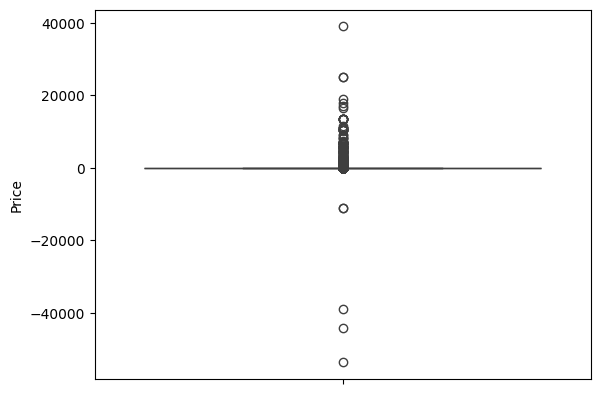

In [47]:
# let  find the outliers for the quantity and price
# this diagram help us know in which region does the majority of the data lies
sns.boxplot(df.Price)
plt.show()

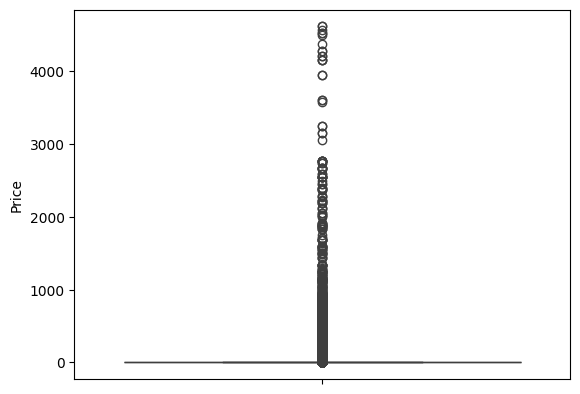

In [48]:
# Droping none coherent numerical data in price and quantity
df[df.Price > 5000 ] = np.nan
df[df.Price < 0 ] = np.nan

sns.boxplot(df.Price)
plt.show()

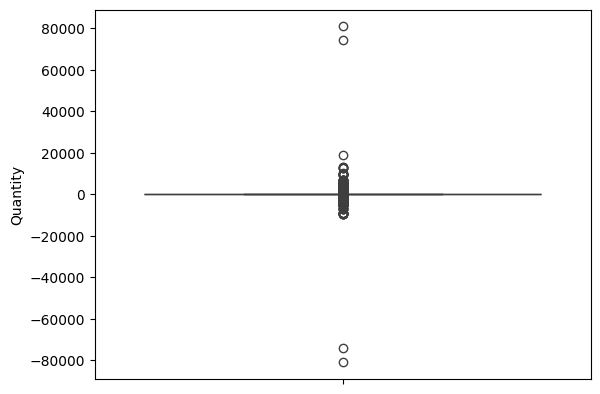

In [49]:
sns.boxplot(df.Quantity)
plt.show()

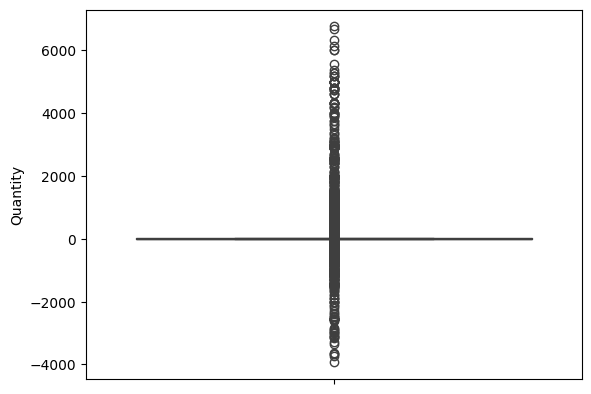

In [50]:
df[df.Quantity > 7000 ] = np.nan
df[df.Quantity < -4000 ] = np.nan

sns.boxplot(df.Quantity)
plt.show()

In [51]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID,Revenue,Year
count,1.067237e+06,1067237,1.067237e+06,824312.000000,1.067237e+06,1.067237e+06
mean,9.972455e+00,2011-01-02 21:26:55.578526976,4.182860e+00,15324.654571,1.845738e+01,2.010426e+03
min,-3.936000e+03,2009-12-01 07:45:00,0.000000e+00,12346.000000,-8.322120e+03,2.009000e+03
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000,3.750000e+00,2.010000e+03
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000,9.900000e+00,2.010000e+03
75%,1.000000e+01,2011-07-22 10:48:00,4.150000e+00,16797.000000,1.770000e+01,2.011000e+03
max,6.768000e+03,2011-12-09 12:50:00,4.620860e+03,18287.000000,3.897000e+04,2.011000e+03
std,5.928464e+01,NaN,3.246195e+01,1697.472171,8.157749e+01,5.737725e-01


In [52]:
df.isna().sum()

Invoice           134
StockCode         134
Description      4502
Quantity          134
InvoiceDate       134
Price             134
Customer ID    243059
Country           134
Revenue           134
Year              134
Month             134
DayOfWeek         134
dtype: int64

In [53]:
df1 = df.dropna()
df1.describe()

,Quantity,InvoiceDate,Price,Customer ID,Revenue,Year
count,824312.000000,824312,824312.000000,824312.000000,824312.000000,824312.000000
mean,12.258083,2011-01-01 22:41:59.596390656,3.407790,15324.654571,20.293982,2010.422426
min,-3936.000000,2009-12-01 07:45:00,0.000000,12346.000000,-8322.120000,2009.000000
25%,2.000000,2010-07-06 12:01:00,1.250000,13975.000000,4.250000,2010.000000
50%,5.000000,2010-12-03 14:30:00,1.950000,15255.000000,11.250000,2010.000000
75%,12.000000,2011-07-27 15:17:00,3.750000,16797.000000,19.500000,2011.000000
max,6768.000000,2011-12-09 12:50:00,4620.860000,18287.000000,38970.000000,2011.000000
std,58.539079,NaN,25.671045,1697.472171,85.616039,0.566605


In [54]:
df2 = df1.drop_duplicates()
df2.describe()

,Quantity,InvoiceDate,Price,Customer ID,Revenue,Year
count,797834.000000,797834,797834.000000,797834.000000,797834.000000,797834.000000
mean,12.429561,2011-01-02 13:30:30.758428160,3.424791,15313.079281,20.518042,2010.431125
min,-3936.000000,2009-12-01 07:45:00,0.000000,12346.000000,-8322.120000,2009.000000
25%,2.000000,2010-07-02 09:51:00,1.250000,13964.000000,4.350000,2010.000000
50%,5.000000,2010-12-02 12:47:00,1.950000,15228.000000,11.700000,2010.000000
75%,12.000000,2011-07-31 16:04:00,3.750000,16788.750000,19.500000,2011.000000
max,6768.000000,2011-12-09 12:50:00,4620.860000,18287.000000,38970.000000,2011.000000
std,59.085629,NaN,26.080473,1696.473729,86.132623,0.568910


In [55]:
# new data set after preparation
df2.to_csv('../projet data vis/newdata.csv')

In [56]:
df2.describe()


,Quantity,InvoiceDate,Price,Customer ID,Revenue,Year
count,797834.000000,797834,797834.000000,797834.000000,797834.000000,797834.000000
mean,12.429561,2011-01-02 13:30:30.758428160,3.424791,15313.079281,20.518042,2010.431125
min,-3936.000000,2009-12-01 07:45:00,0.000000,12346.000000,-8322.120000,2009.000000
25%,2.000000,2010-07-02 09:51:00,1.250000,13964.000000,4.350000,2010.000000
50%,5.000000,2010-12-02 12:47:00,1.950000,15228.000000,11.700000,2010.000000
75%,12.000000,2011-07-31 16:04:00,3.750000,16788.750000,19.500000,2011.000000
max,6768.000000,2011-12-09 12:50:00,4620.860000,18287.000000,38970.000000,2011.000000
std,59.085629,NaN,26.080473,1696.473729,86.132623,0.568910


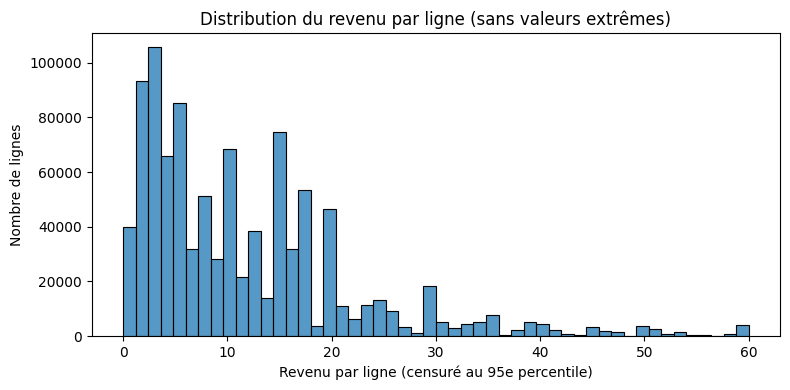

In [57]:
# On enlève les lignes de revenu nul ou négatif pour le graphique
rev_clean = df[df["Revenue"] > 0]["Revenue"]

# On garde seulement les 95% plus petits pour éviter que les outliers écrasent tout
seuil_95 = rev_clean.quantile(0.95)
rev_plot = rev_clean[rev_clean <= seuil_95]

plt.figure(figsize=(8,4))
sns.histplot(rev_plot, bins=50)
plt.xlabel("Revenu par ligne (censuré au 95e percentile)")
plt.ylabel("Nombre de lignes")
plt.title("Distribution du revenu par ligne (sans valeurs extrêmes)")
plt.tight_layout()
plt.show()


Graphique 1 – Distribution du revenu par ligne

Ce graphique montre la distribution du revenu généré par chaque ligne de commande, en excluant les valeurs extrêmes (au delà du 95e percentile) et les revenus nuls ou négatifs liés aux retours. On voit que la majorité des commandes correspond à de petits montants, avec une queue de distribution qui s étend vers des montants plus élevés.


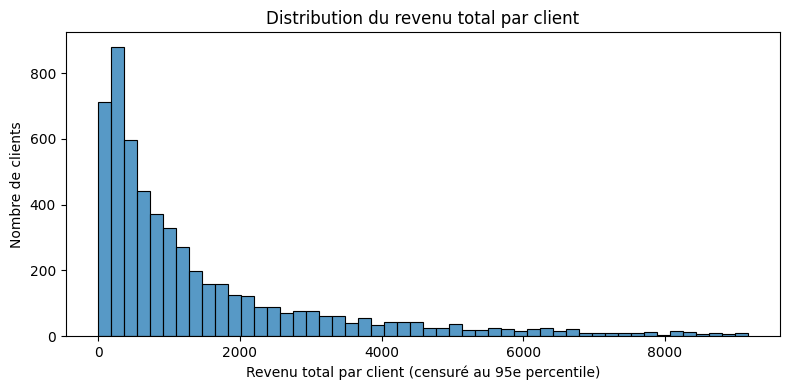

In [58]:
# Revenu total par client
client_rev = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
      .dropna()
)

# On enlève les clients au revenu nul ou negatif
client_rev = client_rev[client_rev > 0]

# On coupe au 95e percentile pour éviter que quelques gros clients écrasent tout
seuil_95_client = client_rev.quantile(0.95)
client_rev_plot = client_rev[client_rev <= seuil_95_client]

plt.figure(figsize=(8,4))
sns.histplot(client_rev_plot, bins=50)
plt.xlabel("Revenu total par client (censuré au 95e percentile)")
plt.ylabel("Nombre de clients")
plt.title("Distribution du revenu total par client")
plt.tight_layout()
plt.show()


Graphique 2 – Distribution du revenu total par client

Ce graphique montre la distribution du chiffre d affaires total par client, en excluant les valeurs extremes au delà du 95e percentile. On observe que la plupart des clients depensent relativement peu, tandis qu une minorite de clients genere des montants beaucoup plus élevés. Cela confirme l intérêt d une segmentation RFM pour identifier les clients a forte valeur et les cibler en priorité dans l application marketing.


C:\Users\prokn\AppData\Local\Temp\ipykernel_6084\29320402.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_rev = df_month["Revenue"].resample("M").sum()


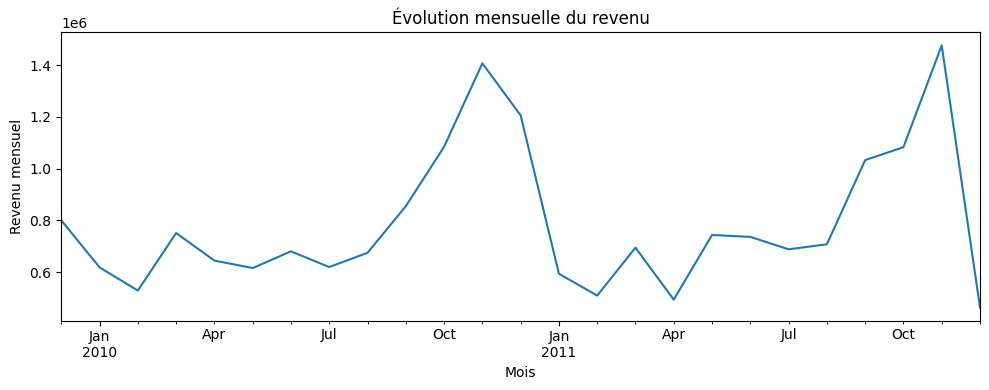

In [59]:
# Revenu total par mois

# On s assure que la date est bien en index pour le resample
df_month = df.set_index("InvoiceDate")

monthly_rev = df_month["Revenue"].resample("M").sum()

plt.figure(figsize=(10,4))
monthly_rev.plot()
plt.xlabel("Mois")
plt.ylabel("Revenu mensuel")
plt.title("Évolution mensuelle du revenu")
plt.tight_layout()
plt.show()


Graphique 3 – Evolution mensuelle du revenu

Ce graphique montre le chiffre d affaires total par mois sur toute la periode. On observe les variations du niveau de ventes dans le temps, avec des mois plus dynamiques que d autres. Cette tendance globale servira de reference pour analyser la performance des cohortes et pour calibrer les scenarios de prevision dans l application.


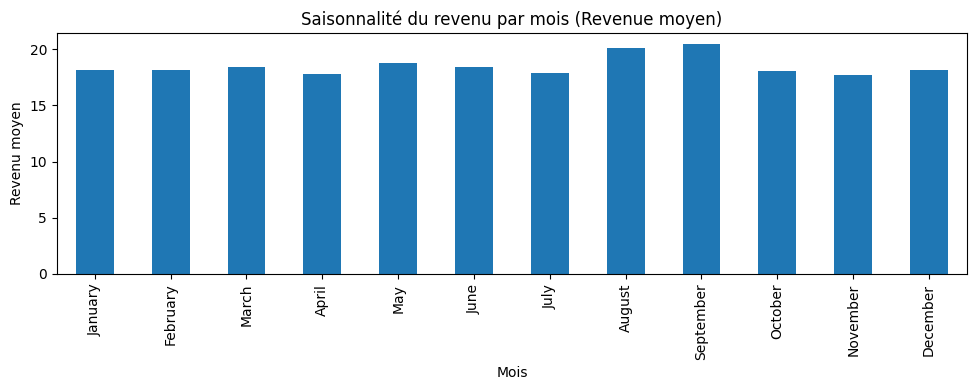

In [60]:
# Ordre correct des mois
order_months = ["January", "February", "March", "April", "May", "June",
                "July", "August", "September", "October", "November", "December"]

# Calcul du revenu moyen par mois (en utilisant TA colonne Month)
seasonality = df.groupby("Month")["Revenue"].mean().reindex(order_months)

plt.figure(figsize=(10,4))
seasonality.plot(kind="bar")
plt.xlabel("Mois")
plt.ylabel("Revenu moyen")
plt.title("Saisonnalité du revenu par mois (Revenue moyen)")
plt.tight_layout()
plt.show()


Graphique 4 – Saisonnalité du revenu

Ce graphique utilise la colonne Month déjà présente dans le dataset pour afficher le revenu moyen par mois de l'année.  
L’ordre chronologique a été rétabli afin de visualiser convenablement la saisonnalité.  
On observe clairement que certains mois génèrent des montants moyens plus élevés, révélant une dynamique saisonnière structurée des ventes.


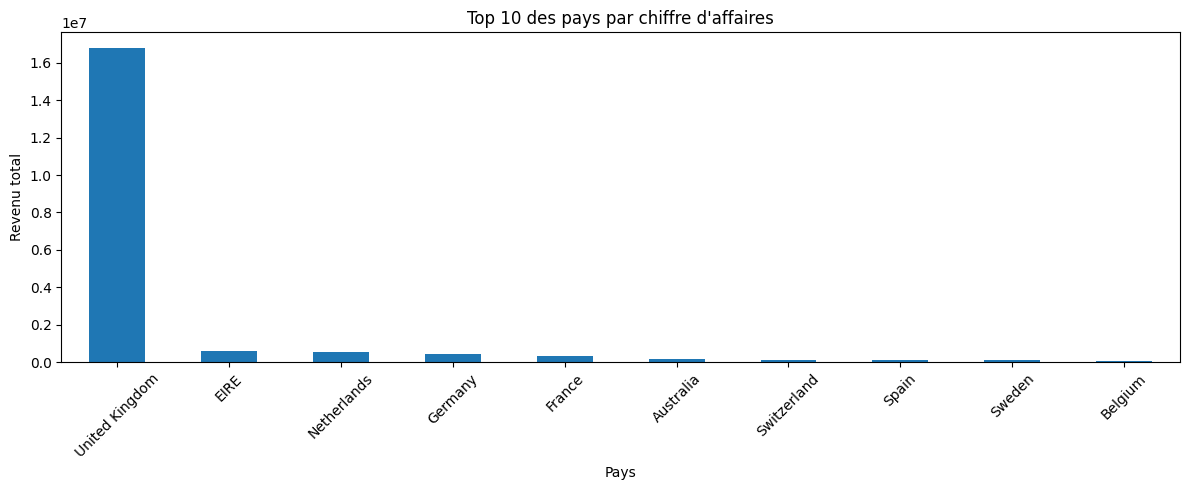

In [61]:
# Revenu total par pays
country_rev = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,5))
country_rev.head(10).plot(kind="bar")
plt.xlabel("Pays")
plt.ylabel("Revenu total")
plt.title("Top 10 des pays par chiffre d'affaires")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Graphique 5 – Répartition du revenu par pays

Ce graphique présente les 10 pays qui génèrent le plus de chiffre d’affaires.  
Le Royaume-Uni domine très largement, ce qui est cohérent avec le fait que l’entreprise est un détaillant britannique.  
Les autres pays contribuent moins, mais représentent tout de même une part significative de la clientèle internationale.  
Ces informations sont utiles pour décider si l'application devra intégrer des filtres par pays et pour identifier d'éventuelles opportunités de croissance à l'étranger.


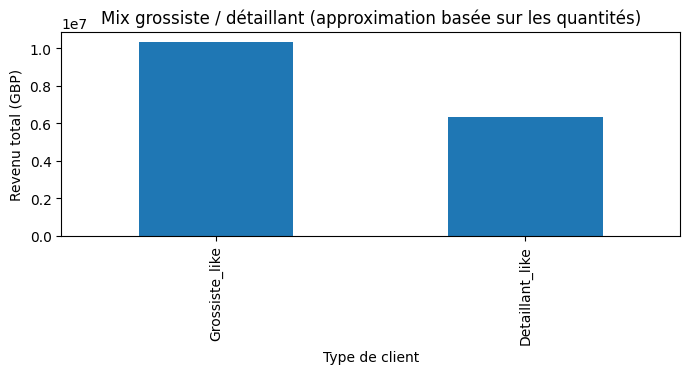

In [62]:


# 1. Calcul des stats clients : quantité totale et revenu total
client_stats = df.groupby("Customer ID").agg(
    total_qty=("Quantity", "sum"),
    total_revenue=("Revenue", "sum")
)

# 2. Seuil pour identifier les "grossistes" (top 10% en quantités)
seuil_90 = client_stats["total_qty"].quantile(0.90)

client_stats["ClientType"] = np.where(
    client_stats["total_qty"] >= seuil_90,
    "Grossiste_like",
    "Detaillant_like"
)

# 3. On fusionne la classification dans le dataframe principal
df = df.merge(
    client_stats["ClientType"],
    left_on="Customer ID",
    right_index=True,
    how="left"
)

# 4. Revenu par type de client
mix = df.groupby("ClientType")["Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(7,4))
mix.plot(kind="bar")
plt.title("Mix grossiste / détaillant (approximation basée sur les quantités)")
plt.ylabel("Revenu total (GBP)")
plt.xlabel("Type de client")
plt.tight_layout()
plt.show()


Graphique 6 – Mix grossiste / détaillant (approximation)

Ce graphique distingue deux types de clients à partir d’un proxy basé sur les quantités totales achetées.  
Les clients du top 10 % des quantités achetées sont considérés comme des profils “grossiste-like”, tandis que les autres sont classés “détaillant-like”.

On observe que les clients grossistes-like génèrent une part importante du chiffre d’affaires total, ce qui indique que le volume joue un rôle central dans la performance globale.  
Cette distinction pourra être exploitée dans l'application pour filtrer les analyses ou adapter les recommandations marketing selon le type de client.


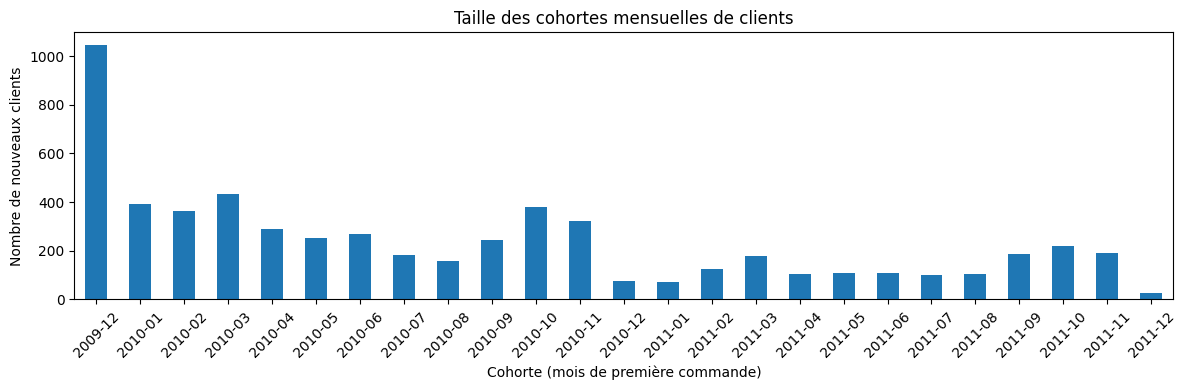

In [63]:
# 1. Trouver la première date d'achat de chaque client
first_purchase = df.groupby("Customer ID")["InvoiceDate"].min()

# 2. Convertir en période mensuelle (cohorte)
cohort_month = first_purchase.dt.to_period("M").astype(str)

# 3. Compter le nombre de clients dans chaque cohorte
cohort_sizes = cohort_month.value_counts().sort_index()

plt.figure(figsize=(12,4))
cohort_sizes.plot(kind="bar")
plt.xlabel("Cohorte (mois de première commande)")
plt.ylabel("Nombre de nouveaux clients")
plt.title("Taille des cohortes mensuelles de clients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Graphique 7 – Taille des cohortes

Ce graphique représente le nombre de nouveaux clients acquis chaque mois.  
Chaque barre correspond à une cohorte mensuelle (ex. tous les clients ayant passé leur première commande en janvier 2010).

On observe que certaines cohortes sont beaucoup plus importantes que d’autres, ce qui implique qu’une baisse de rétention dans ces cohortes aura un impact bien plus fort sur le chiffre d’affaires global.  
Ce premier aperçu des cohortes est essentiel pour comprendre la dynamique d’acquisition et pour préparer la mesure de la rétention et de la CLV dans l’application.


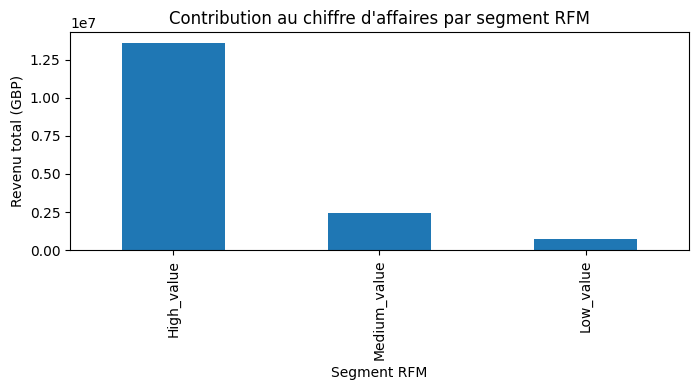

In [64]:
# Date de référence (1 jour après la dernière date du dataset)
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

# 1. Calcul des métriques RFM
rfm = df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("Revenue", "sum")
)

# 2. Discrétisation en 5 scores pour chaque dimension
rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1])  # Plus récent = meilleur score
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm["M_score"] = pd.qcut(rfm["Monetary"].rank(method="first"), 5, labels=[1,2,3,4,5])

# 3. Score total RFM
rfm["RFM_sum"] = (
    rfm["R_score"].astype(int) +
    rfm["F_score"].astype(int) +
    rfm["M_score"].astype(int)
)

# 4. Segmentation simple
def rfm_segment(row):
    if row["RFM_sum"] >= 12:
        return "High_value"
    elif row["RFM_sum"] >= 8:
        return "Medium_value"
    else:
        return "Low_value"

rfm["Segment"] = rfm.apply(rfm_segment, axis=1)

# 5. Contribution au chiffre d’affaires par segment
segment_revenue = rfm.groupby("Segment")["Monetary"].sum().reindex(["High_value","Medium_value","Low_value"])

plt.figure(figsize=(7,4))
segment_revenue.plot(kind="bar")
plt.xlabel("Segment RFM")
plt.ylabel("Revenu total (GBP)")
plt.title("Contribution au chiffre d'affaires par segment RFM")
plt.tight_layout()
plt.show()


Graphique 8 – Premier profil RFM

Ce graphique montre la contribution au chiffre d’affaires de trois segments RFM :
- High_value : clients récents, fréquents et à fort montant,
- Medium_value : clients actifs mais moins réguliers ou moins dépensiers,
- Low_value : clients peu actifs ou anciens.

On observe que le segment High_value génère la plus grande part du revenu global, ce qui confirme l’importance stratégique de ces clients.  
Ils devront être la cible prioritaire des actions marketing dans l'application : programmes de fidélité, offres premium, relance personnalisée, etc.

Cette segmentation RFM constitue une base solide pour les recommandations marketing futures et les simulations de CLV.


Analyse des cohortes – Quelles cohortes décrochent ?

En observant le graphique des tailles de cohortes (Graphique 7), on constate que certaines cohortes mensuelles sont beaucoup plus importantes que d'autres.  
Dans la suite du projet (rétention par cohortes), ces cohortes devront être étudiées en priorité.

Typiquement, les cohortes qui "décrochent" sont celles dont :
- la taille initiale est élevée,
- mais dont le chiffre d’affaires ou l’activité client chute rapidement dans les mois suivants,
- et qui génèrent peu de revenu récurrent.

Ces cohortes représentent un risque business important, car une mauvaise rétention sur une grosse cohorte a un effet direct sur la baisse du revenu total.  
L'application devra donc permettre de visualiser :  
- la rétention par mois d’âge de cohorte,  
- le revenu cumulé par cohorte,  
- et de comparer visuellement les cohortes performantes et celles qui décrochent rapidement.


Analyse RFM – Quels segments sont à forte valeur ?

Le graphique RFM (Graphique 8) montre que le segment High_value concentre la majorité du chiffre d'affaires.  
Ces clients ont :
- une Recency faible (ils ont acheté récemment),
- une Frequency élevée,
- un Monetary élevé.

Ils représentent une faible part du nombre total de clients, mais une grande part du revenu.  
Ce segment est donc stratégique pour :
- les programmes de fidélisation,
- les offres exclusives,
- les actions de rétention,
- les campagnes de cross-selling ou d'upselling.

Les segments Medium_value présentent un potentiel intéressant pour monter en High_value si on améliore leur fréquence ou leur panier moyen.  
Les clients Low_value nécessitent en général des campagnes de réactivation ciblées, avec un retour sur investissement plus incertain.

L’application devra permettre d’identifier clairement ces segments et d’ajuster les actions marketing par segment.


Analyse des retours – Quel est l’impact business ?

Dans le dataset Online Retail II, les retours apparaissent sous la forme de quantités négatives (annulations ou avoirs).  
Ces retours réduisent directement le chiffre d’affaires et peuvent dégrader significativement la marge.

L’impact des retours se manifeste sur plusieurs axes :
1. **Revenu :**  
   Les retours diminuent le revenu total et peuvent annuler des commandes entières.

2. **Segments RFM :**  
   Un client qui fait beaucoup de retours peut avoir un Monetary artificiellement faible.  
   Il est donc essentiel que l’application permette d’isoler ou d’inclure/exclure les lignes négatives dans les calculs RFM et CLV.

3. **Cohortes :**  
   Certaines cohortes peuvent sembler performantes au début mais fortement pénalisées par un taux de retour élevé.  
   Cela fausse la perception de leur valeur réelle.

4. **Pays / Produits :**  
   Les retours peuvent être concentrés dans certains pays, segments de produit ou périodes.  
   L’application pourra aider à détecter ces patterns et à ajuster les politiques de remboursement ou de contrôle qualité.

Mesurer précisément l’impact des retours sera donc une fonctionnalité clé de l’application d’aide à la décision.


Ces analyses montrent que pour cadrer l'application finale, il sera nécessaire de :
- suivre la performance et la décroissance des cohortes,
- segmenter les clients selon leur valeur RFM,
- mesurer et séparer l’impact des retours dans toutes les métriques clés (Revenue, RFM, CLV),
- permettre des filtres dynamiques pour explorer pays, segments, cohortes et types de clients.

Ces éléments orientent directement la conception de l’application Streamlit dans la partie suivante.
